To build and evaluate a Hospital Admission Decision Support System Using Machine Learning Classification, The systesm will be able to tell the patients Expected Hospital days of stay and Medical bill cost. To prepare the patient mind and improve treatment outcome through communication

In [53]:
# Importing the required Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import joblib


# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# DOWLOAD DATASET FROM COLABE
import kagglehub
path = kagglehub.dataset_download("olagokeblissman/luth-hospital-enhanced-dataset")

Using Colab cache for faster access to the 'luth-hospital-enhanced-dataset' dataset.


In [3]:
# Checking file location
import os
os.listdir(path)

['LUTH_Hospital_Enhanced_Dataset.xlsx', '.nfs000000005822025a00000057']

In [4]:
# file_path
file_path = os.path.join(path, 'LUTH_Hospital_Enhanced_Dataset.xlsx')
file_path

'/kaggle/input/luth-hospital-enhanced-dataset/LUTH_Hospital_Enhanced_Dataset.xlsx'

In [5]:
#Reading the xlsx file using pandas
df = pd.read_excel(file_path)
df.head(5)

,Patient ID,Name,Age,Gender,Department,Diagnosis,Treatment,Doctor,Visit Date,Stay Duration (days),Cost (Naira),Ward,Payment Method,Outcome,Follow-Up Required,Satisfaction Score (1-5),Admission Time,Discharge Time
0,LUTH-1000,Patient_1,44,Female,Oncology,Malaria,Surgery,Dr. Obi,2024-02-21,10,243721.97,Ward D,Cash,Deceased,No,4,2024-02-21 13:13:00,2024-03-02 13:13:00
1,LUTH-1001,Patient_2,51,Male,Neurology,Cancer,Referral,Dr. Bello,2024-11-22,13,150679.18,Ward C,Insurance,Under Observation,No,1,2024-11-22 17:22:00,2024-12-05 17:22:00
2,LUTH-1002,Patient_3,20,Female,Cardiology,Fracture,Physiotherapy,Dr. Johnson,2024-09-18,14,97198.81,Ward E,Cash,Deceased,Yes,4,2024-09-18 10:34:00,2024-10-02 10:34:00
3,LUTH-1003,Patient_4,73,Male,Orthopedics,Infection,Physiotherapy,Dr. Okafor,2024-09-14,11,178102.61,Ward E,Card,Recovered,No,3,2024-09-14 11:34:00,2024-09-25 11:34:00
4,LUTH-1004,Patient_5,78,Male,Pediatrics,Fracture,Surgery,Dr. Musa,2024-07-08,15,201972.05,Ward E,Insurance,Referred,No,4,2024-07-08 14:52:00,2024-07-23 14:52:00


EDA (Data exploration, cleaning and Preprocessing)

In [6]:
# Dataset size

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 500
Columns: 18


In [7]:
# Data describe
df.describe()

,Age,Visit Date,Stay Duration (days),Cost (Naira),Satisfaction Score (1-5)
count,500.000000,500,500.000000,500.000000,500.000000
mean,45.196000,2024-06-27 01:14:52.800000,8.020000,132347.486460,2.986000
min,1.000000,2024-01-01 00:00:00,1.000000,10211.400000,1.000000
25%,23.000000,2024-03-28 12:00:00,4.000000,75035.492500,2.000000
50%,44.500000,2024-06-26 12:00:00,8.000000,130198.560000,3.000000
75%,68.000000,2024-09-27 06:00:00,12.000000,188105.530000,4.000000
max,90.000000,2024-12-31 00:00:00,15.000000,249943.290000,5.000000
std,25.939377,NaN,4.386123,68992.844624,1.390565


In [8]:
# Check Missing Values
df.isnull().sum()

,0
Patient ID,0
Name,0
Age,0
Gender,0
Department,0
Diagnosis,0
Treatment,0
Doctor,0
Visit Date,0
Stay Duration (days),0


In [9]:
# Checking the number duplicate
print("Duplicate rows:",
      df.duplicated().sum())

Duplicate rows: 0


In [10]:
# Remove features not need for the model building
drop_columns = [

    "Patient ID",
    "Name",
    "Doctor",
    "Visit Date",
    "Ward",
    "Payment Method",
    "Outcome",
    "Follow-Up Required",
    "Satisfaction Score (1-5)",
    "Admission Time",
    "Discharge Time"

]


df.drop(
    columns=drop_columns,
    inplace=True
)


df.head()

,Age,Gender,Department,Diagnosis,Treatment,Stay Duration (days),Cost (Naira)
0,44,Female,Oncology,Malaria,Surgery,10,243721.97
1,51,Male,Neurology,Cancer,Referral,13,150679.18
2,20,Female,Cardiology,Fracture,Physiotherapy,14,97198.81
3,73,Male,Orthopedics,Infection,Physiotherapy,11,178102.61
4,78,Male,Pediatrics,Fracture,Surgery,15,201972.05


In [11]:

# Checking columns in Categorical
categorical_columns = [

    "Gender",
    "Department",
    "Diagnosis",
    "Treatment"

]


for col in categorical_columns:

    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )


for col in categorical_columns:

    print("\n",col)

    print(df[col].unique())


 Gender
['Female' 'Male']

 Department
['Oncology' 'Neurology' 'Cardiology' 'Orthopedics' 'Pediatrics'
 'Emergency' 'General Surgery']

 Diagnosis
['Malaria' 'Cancer' 'Fracture' 'Infection' 'Hypertension' 'Diabetes'
 'Stroke']

 Treatment
['Surgery' 'Referral' 'Physiotherapy' 'Observation' 'Chemotherapy'
 'Medication']


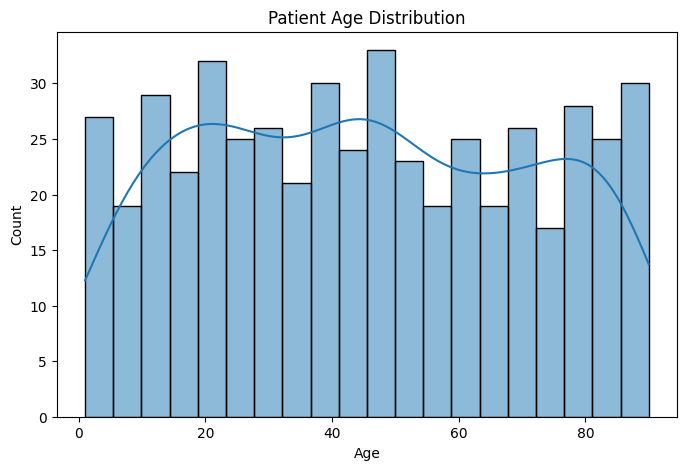

In [12]:
# Age distribution
plt.figure(figsize=(8,5))


sns.histplot(
    df["Age"],
    bins=20,
    kde=True
)


plt.title(
    "Patient Age Distribution"
)

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()


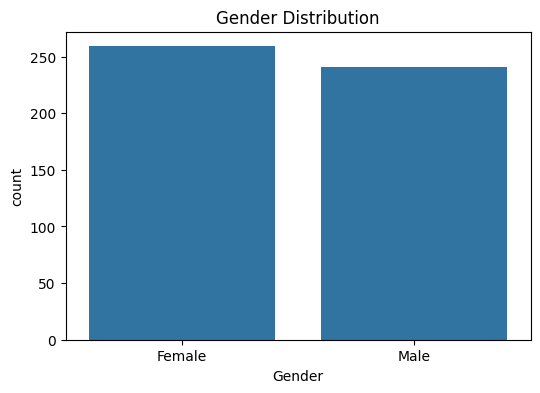

In [13]:
# Gender distribution
plt.figure(figsize=(6,4))


sns.countplot(
    data=df,
    x="Gender"
)


plt.title(
    "Gender Distribution"
)

plt.show()

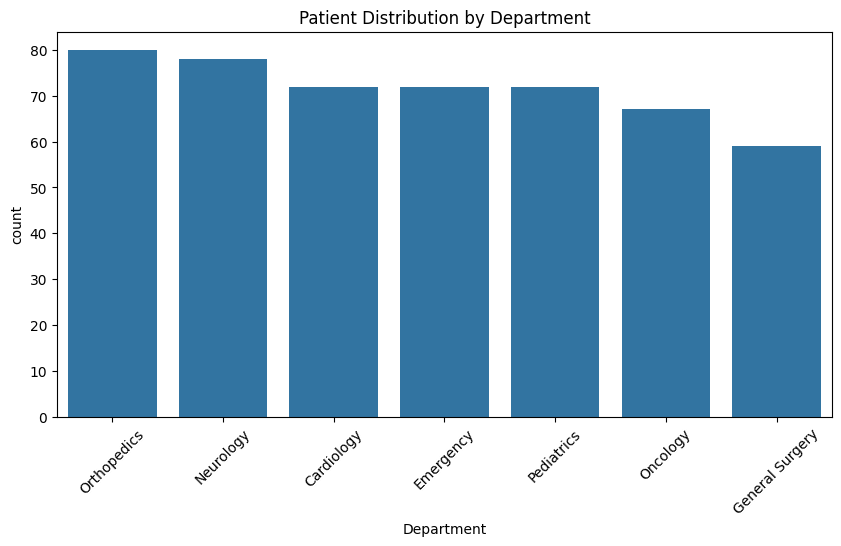

In [14]:
# Depart distribution
plt.figure(figsize=(10,5))


sns.countplot(
    data=df,
    x="Department",
    order=df["Department"].value_counts().index
)


plt.xticks(rotation=45)

plt.title(
    "Patient Distribution by Department"
)

plt.show()

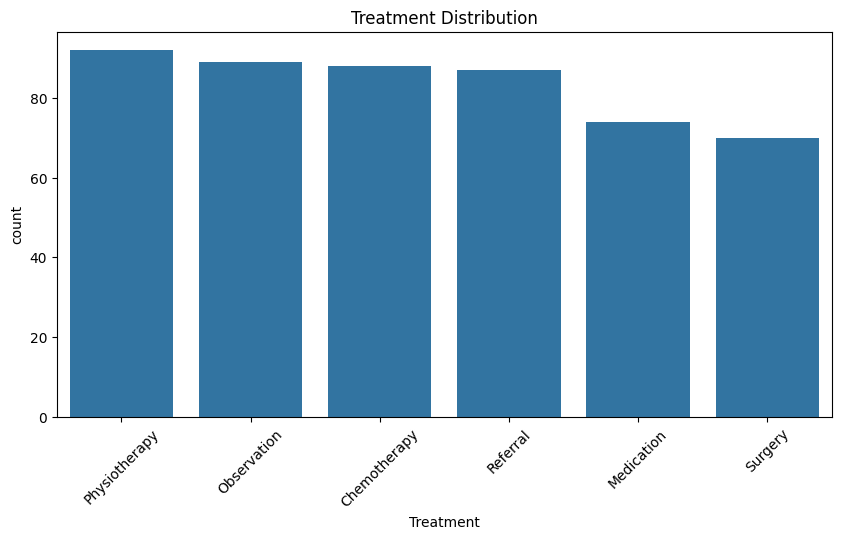

In [15]:
# Treatment Distribution
plt.figure(figsize=(10,5))


sns.countplot(
    data=df,
    x="Treatment",
    order=df["Treatment"].value_counts().index
)


plt.xticks(rotation=45)

plt.title(
    "Treatment Distribution"
)

plt.show()

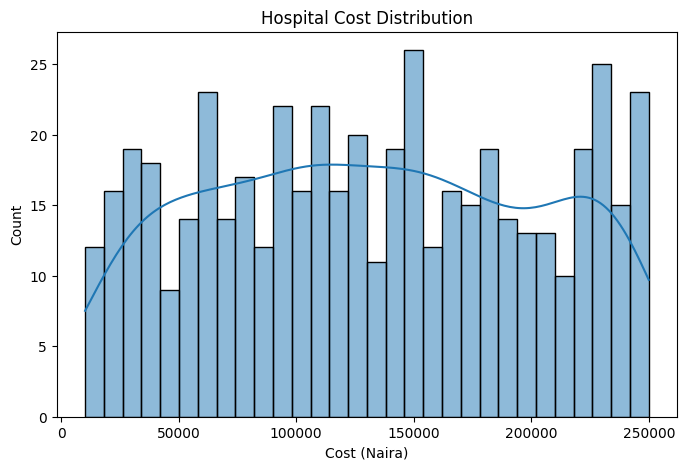

In [16]:
# Cost distribution
plt.figure(figsize=(8,5))


sns.histplot(
    df["Cost (Naira)"],
    bins=30,
    kde=True
)


plt.title(
    "Hospital Cost Distribution"
)

plt.xlabel(
    "Cost (Naira)"
)

plt.show()

FEATURE ENGINEERING

In [17]:
# Hospital stay category
df["Stay_Category"] = np.where(

    df["Stay Duration (days)"] <= 7,

    "Short Stay",

    "Long Stay"

)

df["Stay_Category"].value_counts()

,count
Stay_Category,
Long Stay,264
Short Stay,236


In [18]:
# Cost Category Using Quartiles
Q1 = df["Cost (Naira)"].quantile(0.50)


def create_bill_category(cost):

    if cost <= Q1:

        return "Low"

    else:

        return "High"



df["Bill_Category"] = (

    df["Cost (Naira)"]
    .apply(create_bill_category)

)


df["Bill_Category"].value_counts()

,count
Bill_Category,
High,250
Low,250


In [19]:
df["Gender"] = df["Gender"].str.strip().str.title()

df["Department"] = df["Department"].str.strip().str.title()

df["Diagnosis"] = df["Diagnosis"].str.strip().str.title()

Creating Encoderds

In [20]:
# Model Features Encoding
gender_encoder = LabelEncoder()
department_encoder = LabelEncoder()
diagnosis_encoder = LabelEncoder()

In [21]:
df["Gender"] = gender_encoder.fit_transform(df["Gender"])

df["Department"] = department_encoder.fit_transform(df["Department"])

df["Diagnosis"] = diagnosis_encoder.fit_transform(df["Diagnosis"])

In [22]:
# print(gender_encoder.classes_)

In [23]:
# Model Target Encoding
stay_encoder = LabelEncoder()

treatment_encoder = LabelEncoder()

bill_encoder = LabelEncoder()

In [24]:
df["Stay_Category"] = (

    stay_encoder
    .fit_transform(
        df["Stay_Category"]
    )

)



df["Treatment"] = (

    treatment_encoder
    .fit_transform(
        df["Treatment"]
    )

)



df["Bill_Category"] = (

    bill_encoder
    .fit_transform(
        df["Bill_Category"]
    )

)

# Preparing the Data ( Model features(x) and Model target (y))

In [25]:
X = df[
[
"Age",
"Gender",
"Department",
"Diagnosis"
]
]

In [26]:
y_stay = df["Stay_Category"]

y_treatment = df["Treatment"]

y_bill = df["Bill_Category"]

In [27]:
def train_and_select_model(X,y):


    X_train, X_test, y_train, y_test = train_test_split(

        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y

    )


    models = {

        "Logistic Regression":
        LogisticRegression(max_iter=1000),


        "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),


        "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )

    }



    scores={}


    best_model=None

    best_score=0



    for name,model in models.items():


        model.fit(
            X_train,
            y_train
        )


        prediction = model.predict(
            X_test
        )


        accuracy = accuracy_score(

            y_test,
            prediction

        )


        scores[name]=accuracy



        if accuracy > best_score:

            best_score=accuracy

            best_model=model



    print(scores)

    print(
        "Best Accuracy:",
        best_score
    )


    return (
        best_model,
        X_test,
        y_test
    )

In [28]:
# Hospital Stay Model Trainig
stay_model, X_test_stay, y_test_stay = (

    train_and_select_model(
        X,
        y_stay
    )

)

{'Logistic Regression': 0.58, 'Decision Tree': 0.46, 'Random Forest': 0.41}
Best Accuracy: 0.58


In [29]:
# Treatment type Model
treatment_model, X_test_treatment, y_test_treatment = (

    train_and_select_model(
        X,
        y_treatment
    )

)

{'Logistic Regression': 0.16, 'Decision Tree': 0.18, 'Random Forest': 0.15}
Best Accuracy: 0.18


#

In [30]:
# Hospital Bill model
bill_model, X_test_bill, y_test_bill = (

    train_and_select_model(
        X,
        y_bill
    )

)

{'Logistic Regression': 0.47, 'Decision Tree': 0.54, 'Random Forest': 0.49}
Best Accuracy: 0.54


Evalutating Models Performance

In [31]:
def evaluate_model(model,X_test,y_test):


    pred = model.predict(
        X_test
    )


    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            pred
        )
    )


    print(
        classification_report(
            y_test,
            pred
        )
    )


    ConfusionMatrixDisplay.from_predictions(

        y_test,
        pred

    )


    plt.show()

Accuracy: 0.58
              precision    recall  f1-score   support

           0       0.57      0.81      0.67        53
           1       0.60      0.32      0.42        47

    accuracy                           0.58       100
   macro avg       0.59      0.57      0.54       100
weighted avg       0.59      0.58      0.55       100



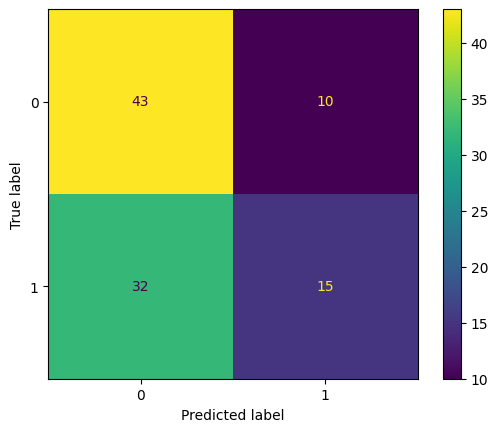

In [32]:
# Evaluate the Stay Model
evaluate_model(
    stay_model,
    X_test_stay,
    y_test_stay
)

Accuracy: 0.54
              precision    recall  f1-score   support

           0       0.53      0.66      0.59        50
           1       0.55      0.42      0.48        50

    accuracy                           0.54       100
   macro avg       0.54      0.54      0.53       100
weighted avg       0.54      0.54      0.53       100



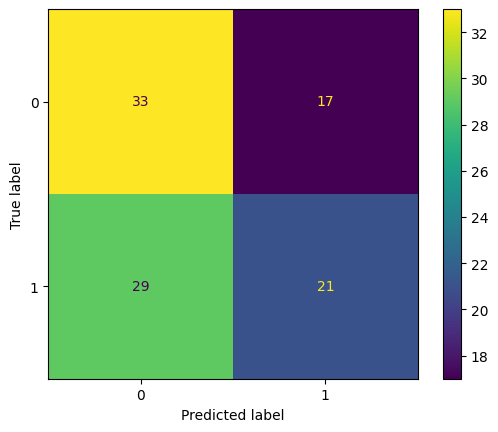

In [33]:
# Evaluate ther Hospital Cost Model
evaluate_model(
    bill_model,
    X_test_bill,
    y_test_bill
)

Accuracy: 0.18
              precision    recall  f1-score   support

           0       0.09      0.06      0.07        18
           1       0.33      0.20      0.25        15
           2       0.28      0.39      0.33        18
           3       0.15      0.17      0.16        18
           4       0.15      0.18      0.16        17
           5       0.07      0.07      0.07        14

    accuracy                           0.18       100
   macro avg       0.18      0.18      0.17       100
weighted avg       0.18      0.18      0.17       100



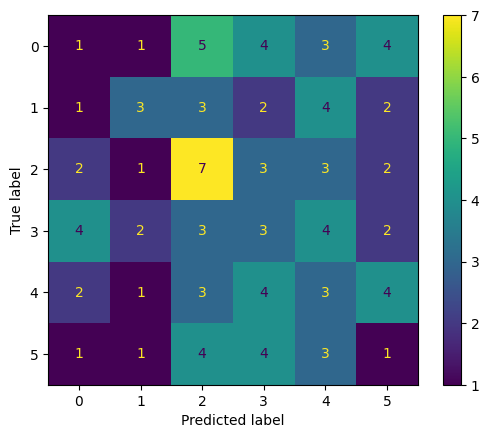

In [34]:
# Evaluate the treatment model performance
evaluate_model(
    treatment_model,
    X_test_treatment,
    y_test_treatment
)

Model Testing with Records

In [51]:
#Testing the model with some fictional record

Test_1 = pd.DataFrame({

    "Age":[18],

    "Gender":[
        gender_encoder.transform(["Female"])[0]
    ],

    "Department":[
        department_encoder.transform(["Oncology"])[0]
    ],

    "Diagnosis":[
        diagnosis_encoder.transform(["Cancer"])[0]
    ]

})

Test_1

,Age,Gender,Department,Diagnosis
0,18,0,4,0


In [52]:
#Treatment Prediction
treatment_encoder.inverse_transform(
    treatment_model.predict(sample)
)


#Bill Prediction
bill_encoder.inverse_transform(
    bill_model.predict(sample)
)


# Hospital duration prediction
stay_encoder.inverse_transform(
    stay_model.predict(sample)
)


array(['Long Stay'], dtype=object)

Trained Model Saving using joblib

In [54]:
# create the folder (models) to save the models trained
os.makedirs("models", exist_ok=True)

In [56]:
# Save Stay Prediction Model
joblib.dump(
    stay_model,
    "models/stay_model.joblib"
)

# Save Treatment Prediction Model
joblib.dump(
    treatment_model,
    "models/treatment_model.joblib"
)

# Save Medical Bill Prediction Model
joblib.dump(
    bill_model,
    "models/bill_model.joblib"
)

print("Models saved successfully!")

Models saved successfully!
